# Retention Root-Cause Analysis — Data Cleaning & EDA

**Business Problem:** The company is losing roughly 1 in 6 customers, and retention efforts are currently reactive rather than targeted. This notebook investigates which behavioral and service factors are most strongly associated with churn, and identifies which at-risk customer segments deserve the highest-priority retention intervention.

**Dataset:** E-commerce customer churn data — 5,630 rows, one snapshot record per customer. Source: Kaggle (E Commerce Dataset.xlsx).


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)


## 1. Load Data

In [9]:

df = pd.read_excel(r"C:\Users\acer\OneDrive\Desktop\customer-churn-retention-analytics\data\raw\E_Commerce_Dataset.xlsx")


In [10]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [11]:
df.shape

(5630, 20)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

**What I'm checking here:** row/column count, data types, and a first look at the structure before doing anything else. 5,630 rows, 20 columns, mostly numeric with a handful of categorical fields.

## 2. Structure & Data Quality Checks

In [13]:
print("Columns with missing values: ")
display(df.isnull().sum()[df.isnull().sum() > 0])


Columns with missing values: 


Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64

**Finding:** 7 columns have missing values — Tenure, WarehouseToHome, HourSpendOnApp, OrderAmountHikeFromlastYear, CouponUsed, OrderCount, DaySinceLastOrder. Each has roughly 250–310 nulls (about 4–5% of rows). This is real missing data, not a rounding error, so it needs a proper strategy rather than a blanket drop or impute — handled in Section 3 below.

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['CustomerID'].duplicated().sum()

np.int64(0)

**Finding:** no duplicate rows, no duplicate CustomerIDs. Each row is a unique customer.

In [16]:
categorical_cols = df.select_dtypes("object").columns
categorical_cols


Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')

In [17]:
for col in categorical_cols:
    print("column name: ", col)
    print(df[col].unique())


column name:  PreferredLoginDevice
['Mobile Phone' 'Phone' 'Computer']
column name:  PreferredPaymentMode
['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']
column name:  Gender
['Female' 'Male']
column name:  PreferedOrderCat
['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']
column name:  MaritalStatus
['Single' 'Divorced' 'Married']


**Finding:** this is where I caught the category inconsistencies fixed in Section 4 — `PreferredLoginDevice` had 'Phone' and 'Mobile Phone' as separate values, `PreferredPaymentMode` had 'CC'/'Credit Card' and 'Cash on Delivery'/'COD' as separate values, and `PreferedOrderCat` had 'Mobile'/'Mobile Phone' as separate values. All represent the same real-world category, just written inconsistently in the source data.

In [18]:
numeric_cols = [
    'Tenure',
    'WarehouseToHome',
    'HourSpendOnApp',
    'NumberOfDeviceRegistered',
    'NumberOfAddress',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder',
    'CashbackAmount'
]

df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.00,16.0000,61.00
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.00,20.0000,127.00
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.00,3.0000,5.00
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.00,4.0000,6.00
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.00,6.0000,22.00
OrderAmountHikeFromlastYear,5365.0,15.707922,3.675485,11.0,13.00,15.00,18.0000,26.00
CouponUsed,5374.0,1.751023,1.894621,0.0,1.00,1.00,2.0000,16.00
OrderCount,5372.0,3.008004,2.939680,1.0,1.00,2.00,3.0000,16.00
DaySinceLastOrder,5323.0,4.543491,3.654433,0.0,2.00,3.00,7.0000,46.00
CashbackAmount,5630.0,177.223030,49.207036,0.0,145.77,163.28,196.3925,324.99


**Finding:** unlike a fully synthetic dataset, these columns show real skew — e.g. Tenure's mean (10.2) sits above its median (9.0) with a long tail out to 61 months, and CashbackAmount and DaySinceLastOrder show similar right-skew. One value jumps out immediately: `WarehouseToHome` has a max of 127, while its 75th percentile is only 20 — investigated below.

## 3. Outlier Investigation — WarehouseToHome

The 127 max is way outside the rest of the distribution. Before touching it, I checked how many rows are actually affected and whether they look like a genuine anomaly or a data entry error.

In [19]:
df[df['WarehouseToHome'] > 50][['CustomerID','WarehouseToHome','Churn']]


,CustomerID,WarehouseToHome,Churn
1309,51310,126.0,0
4124,54125,127.0,0


**Finding:** only 2 rows, both with values of 126 and 127, both retained customers (Churn=0), and both isolated far from the rest of the distribution (which tops out around 37). This pattern — two near-identical, far-flung values — looks like a decimal/digit entry error (likely meant to be 12.6 and 12.7) rather than genuine distant customers.

**Decision:** cap at 40 rather than drop the rows entirely. This preserves the other 19 columns of real data for these two customers, instead of losing them outright.

In [20]:
df['WarehouseToHome'] = df['WarehouseToHome'].clip(upper=40)

# confirm the fix
print(df.loc[[1309, 4124], ['CustomerID','WarehouseToHome','Churn']])
print(df['WarehouseToHome'].describe())


      CustomerID  WarehouseToHome  Churn
1309       51310             40.0      0
4124       54125             40.0      0
count    5379.000000
mean       15.607734
std         8.272555
min         5.000000
25%         9.000000
50%        14.000000
75%        20.000000
max        40.000000
Name: WarehouseToHome, dtype: float64


## 4. Missing Value Strategy

Before deciding how to fill these 7 columns, I checked something important: **does missingness itself correlate with churn?** If it does, blindly imputing with the median would erase real signal.

In [21]:
null_cols = ['Tenure','WarehouseToHome','HourSpendOnApp','OrderAmountHikeFromlastYear',
             'CouponUsed','OrderCount','DaySinceLastOrder']

for col in null_cols:
    print(f"\n--- {col} ---")
    print(df.groupby(df[col].isnull())['Churn'].mean().round(3))



--- Tenure ---
Tenure
False    0.162
True     0.307
Name: Churn, dtype: float64

--- WarehouseToHome ---
WarehouseToHome
False    0.161
True     0.335
Name: Churn, dtype: float64

--- HourSpendOnApp ---
HourSpendOnApp
False    0.166
True     0.227
Name: Churn, dtype: float64

--- OrderAmountHikeFromlastYear ---
OrderAmountHikeFromlastYear
False    0.174
True     0.053
Name: Churn, dtype: float64

--- CouponUsed ---
CouponUsed
False    0.175
True     0.031
Name: Churn, dtype: float64

--- OrderCount ---
OrderCount
False    0.173
True     0.070
Name: Churn, dtype: float64

--- DaySinceLastOrder ---
DaySinceLastOrder
False    0.168
True     0.176
Name: Churn, dtype: float64


**Finding — this split into two opposite patterns:**

- **Tenure, WarehouseToHome, HourSpendOnApp:** missing values show *roughly 2x higher* churn rate than present values (e.g. Tenure: 16.2% vs 30.7%). A plausible explanation — the company may not have had time to fully record these fields for customers who churned quickly.
- **OrderAmountHikeFromlastYear, CouponUsed, OrderCount:** missing values show *2.5–5x lower* churn rate (e.g. CouponUsed: 17.5% vs 3.1%). Checked whether this was the same group of customers missing all three at once — it wasn't (0 rows overlap across all three, confirmed below) — so no single shared explanation, but the pattern is real and shouldn't be erased either.
- **DaySinceLastOrder:** essentially flat (16.8% vs 17.6%) — no real signal here, safe to impute normally.

**Decision:** for the 6 columns that show a real relationship with churn, create a missingness flag (1/0) *before* imputing, so the signal is preserved as its own feature even after the null is filled. DaySinceLastOrder gets a plain median fill with no flag.

In [22]:
overlap = df[df['OrderCount'].isnull() & df['CouponUsed'].isnull() & df['OrderAmountHikeFromlastYear'].isnull()]
print(len(overlap), "rows missing all three simultaneously")


0 rows missing all three simultaneously


In [23]:
# Group A: missingness associated with HIGHER churn — flag before imputing
df['Tenure_Missing'] = df['Tenure'].isnull().astype(int)
df['WarehouseToHome_Missing'] = df['WarehouseToHome'].isnull().astype(int)
df['HourSpendOnApp_Missing'] = df['HourSpendOnApp'].isnull().astype(int)

# Group B: missingness associated with LOWER churn — flag before imputing (no shared pattern, so separate flags)
df['OrderCount_Missing'] = df['OrderCount'].isnull().astype(int)
df['CouponUsed_Missing'] = df['CouponUsed'].isnull().astype(int)
df['OrderAmountHike_Missing'] = df['OrderAmountHikeFromlastYear'].isnull().astype(int)

# Now impute all 7 columns with median (DaySinceLastOrder included, no flag needed — no signal found)
for col in ['Tenure','WarehouseToHome','HourSpendOnApp','OrderCount',
            'CouponUsed','OrderAmountHikeFromlastYear','DaySinceLastOrder']:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum().sum(), "total nulls remaining")


0 total nulls remaining


**Result:** 0 nulls remaining, and 6 new flag columns created that preserve the missingness signal for later analysis, rather than silently erasing it.

## 5. Standardizing Inconsistent Categories



In [24]:
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'})
print(df['PreferredLoginDevice'].value_counts())


PreferredLoginDevice
Mobile Phone    3996
Computer        1634
Name: count, dtype: int64


**Finding:** 'Phone' (1,231) and 'Mobile Phone' (2,765) merged into one category (3,996 total) — confirms this was the same thing written two ways, not two genuinely different login methods.

In [25]:
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'CC': 'Credit Card',
    'Cash on Delivery': 'COD',
    'E wallet': 'E-Wallet'
})
print(df['PreferredPaymentMode'].value_counts())


PreferredPaymentMode
Debit Card     2314
Credit Card    1774
E-Wallet        614
COD             514
UPI             414
Name: count, dtype: int64


In [26]:
# Sanity check before merging — confirm this looks like a genuine label duplication, not two real categories
df[df['PreferedOrderCat'].isin(['Mobile','Mobile Phone'])]['PreferedOrderCat'].value_counts()


PreferedOrderCat
Mobile Phone    1271
Mobile           809
Name: count, dtype: int64

**Finding:** 1,271 'Mobile Phone' + 809 'Mobile' — no reason an order-category list would have two separate "mobile" entries with different meanings, so this is safe to merge.

In [27]:
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})
print(df['PreferedOrderCat'].value_counts())


PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64


In [28]:
# Verify Gender and MaritalStatus don't have the same issue, rather than assuming
print(df['Gender'].unique())
print(df['MaritalStatus'].unique())


['Female' 'Male']
['Single' 'Divorced' 'Married']


**Finding:** both are already clean — no inconsistencies to fix.

**Cleaning log summary:** standardized `PreferredLoginDevice` ('Phone' → 'Mobile Phone'), `PreferredPaymentMode` ('CC' → 'Credit Card', 'Cash on Delivery' → 'COD', 'E wallet' → 'E-Wallet'), and `PreferedOrderCat` ('Mobile' → 'Mobile Phone') — all cases where the source data used inconsistent labels for the same real-world category.

## 6. Univariate Analysis

Checking each variable on its own before comparing anything — distribution shape and outliers for numeric columns, category balance for categorical ones.

In [29]:
numeric_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'SatisfactionScore',
                'NumberOfAddress', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


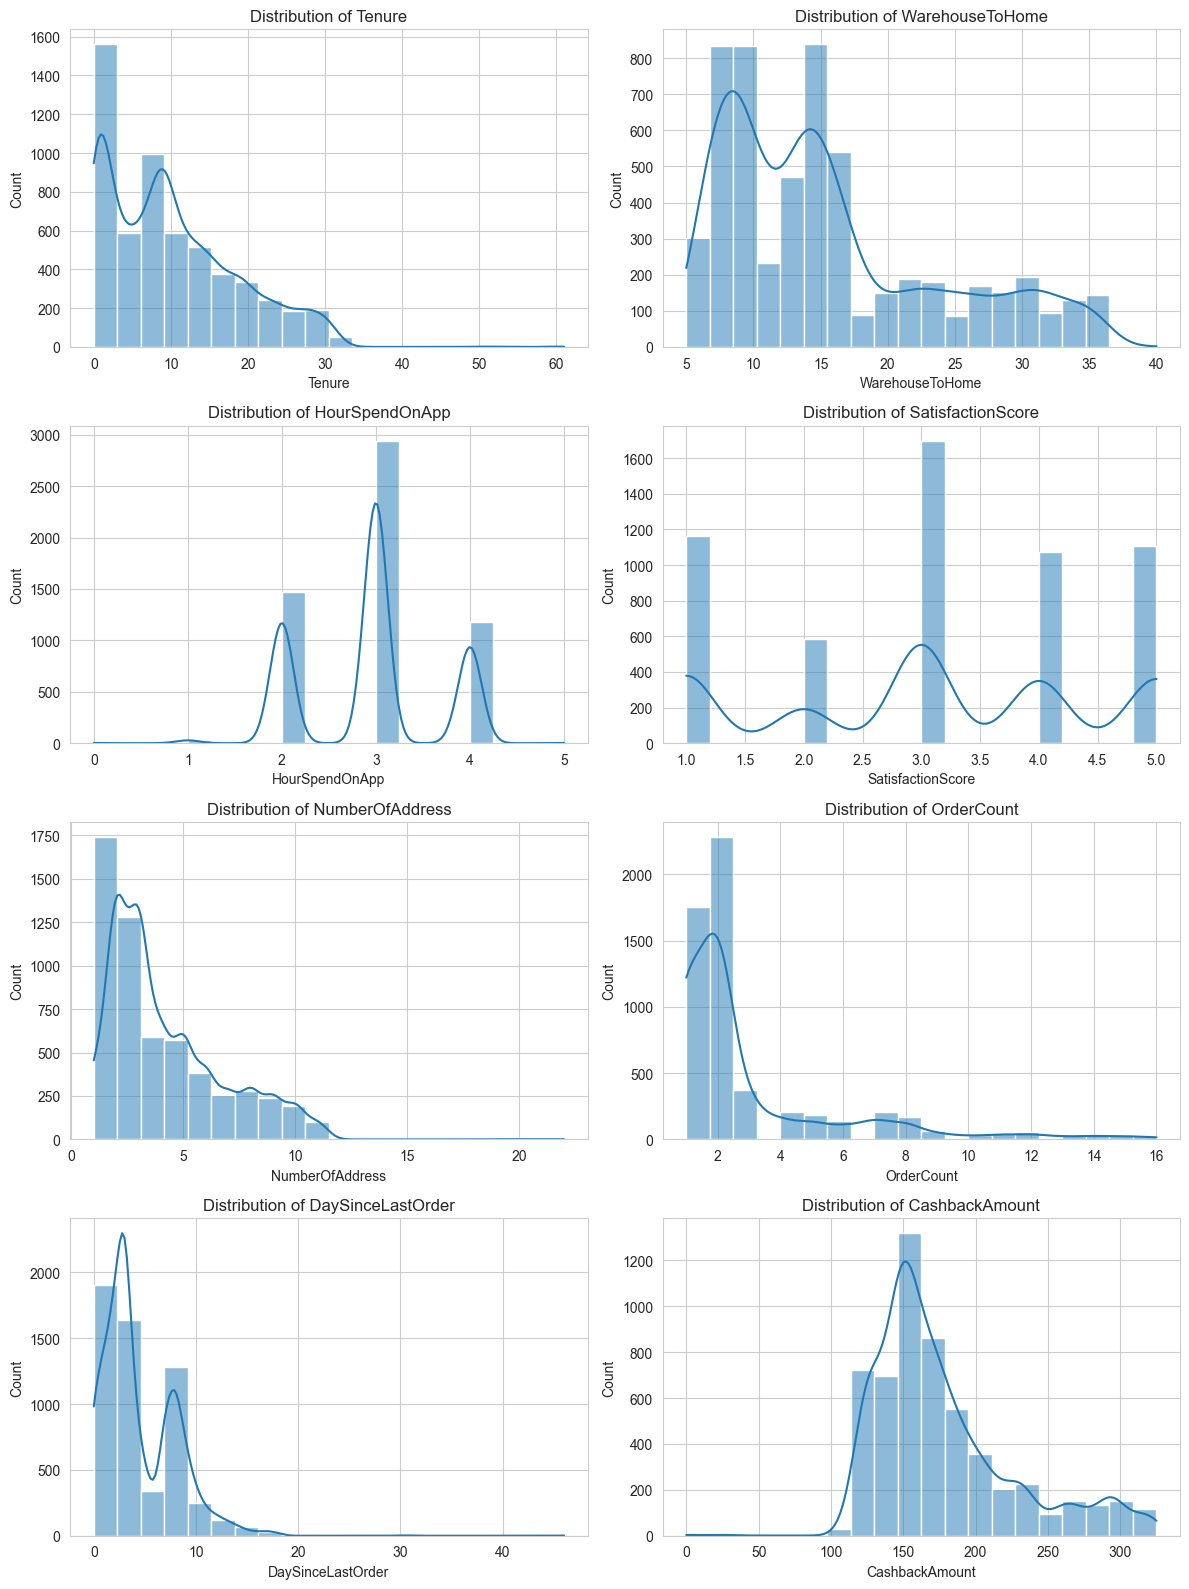

In [30]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


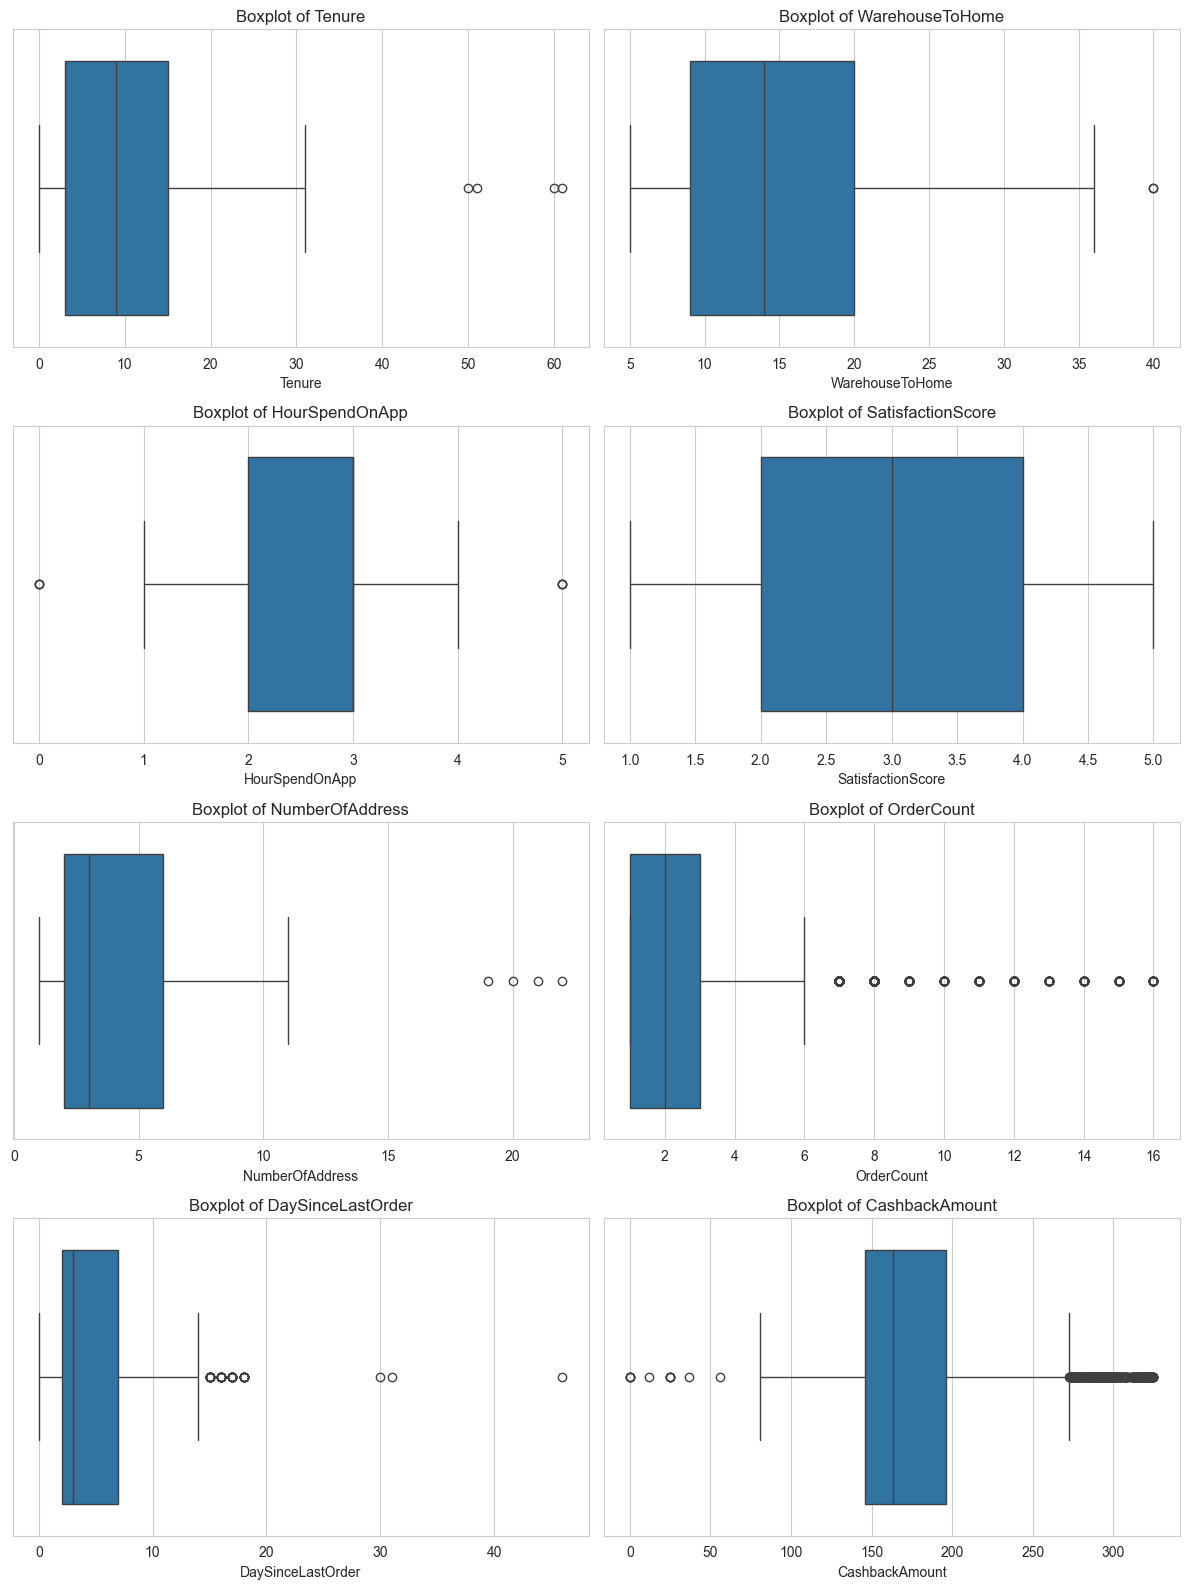

In [31]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


**Findings:**
- **Tenure:** heavily right-skewed with a big spike near 0 — a large share of customers are brand new.
- **WarehouseToHome:** multiple bumps rather than one smooth curve (multimodal) — likely because distances were recorded in delivery-zone bands. Not an error, just a data-collection pattern worth noting.
- **HourSpendOnApp:** sharp isolated spikes at exact integers (2, 3, 4) — this is really a near-categorical variable with only a handful of possible values, not a continuous measure. The "outliers" at 0 and 5 in the boxplot are just the natural edges of a small range, not real anomalies.
- **CouponUsed, OrderCount, DaySinceLastOrder, CashbackAmount:** all right-skewed in a way that looks like genuine customer behavior (a few heavy users pulling a long tail), not synthetic noise.
- **WarehouseToHome boxplot** now shows a clean single outlier at exactly 40 — confirms the cap from Section 3 worked as intended.

In [32]:
categorical_cols = ['Churn', 'PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode',
                     'Gender', 'PreferedOrderCat', 'MaritalStatus', 'Complain']


In [33]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True).round(3) * 100)



--- Churn ---
Churn
0    4682
1     948
Name: count, dtype: int64
Churn
0    83.2
1    16.8
Name: proportion, dtype: float64

--- PreferredLoginDevice ---
PreferredLoginDevice
Mobile Phone    3996
Computer        1634
Name: count, dtype: int64
PreferredLoginDevice
Mobile Phone    71.0
Computer        29.0
Name: proportion, dtype: float64

--- CityTier ---
CityTier
1    3666
3    1722
2     242
Name: count, dtype: int64
CityTier
1    65.1
3    30.6
2     4.3
Name: proportion, dtype: float64

--- PreferredPaymentMode ---
PreferredPaymentMode
Debit Card     2314
Credit Card    1774
E-Wallet        614
COD             514
UPI             414
Name: count, dtype: int64
PreferredPaymentMode
Debit Card     41.1
Credit Card    31.5
E-Wallet       10.9
COD             9.1
UPI             7.4
Name: proportion, dtype: float64

--- Gender ---
Gender
Male      3384
Female    2246
Name: count, dtype: int64
Gender
Male      60.1
Female    39.9
Name: proportion, dtype: float64

--- PreferedOrderCat --

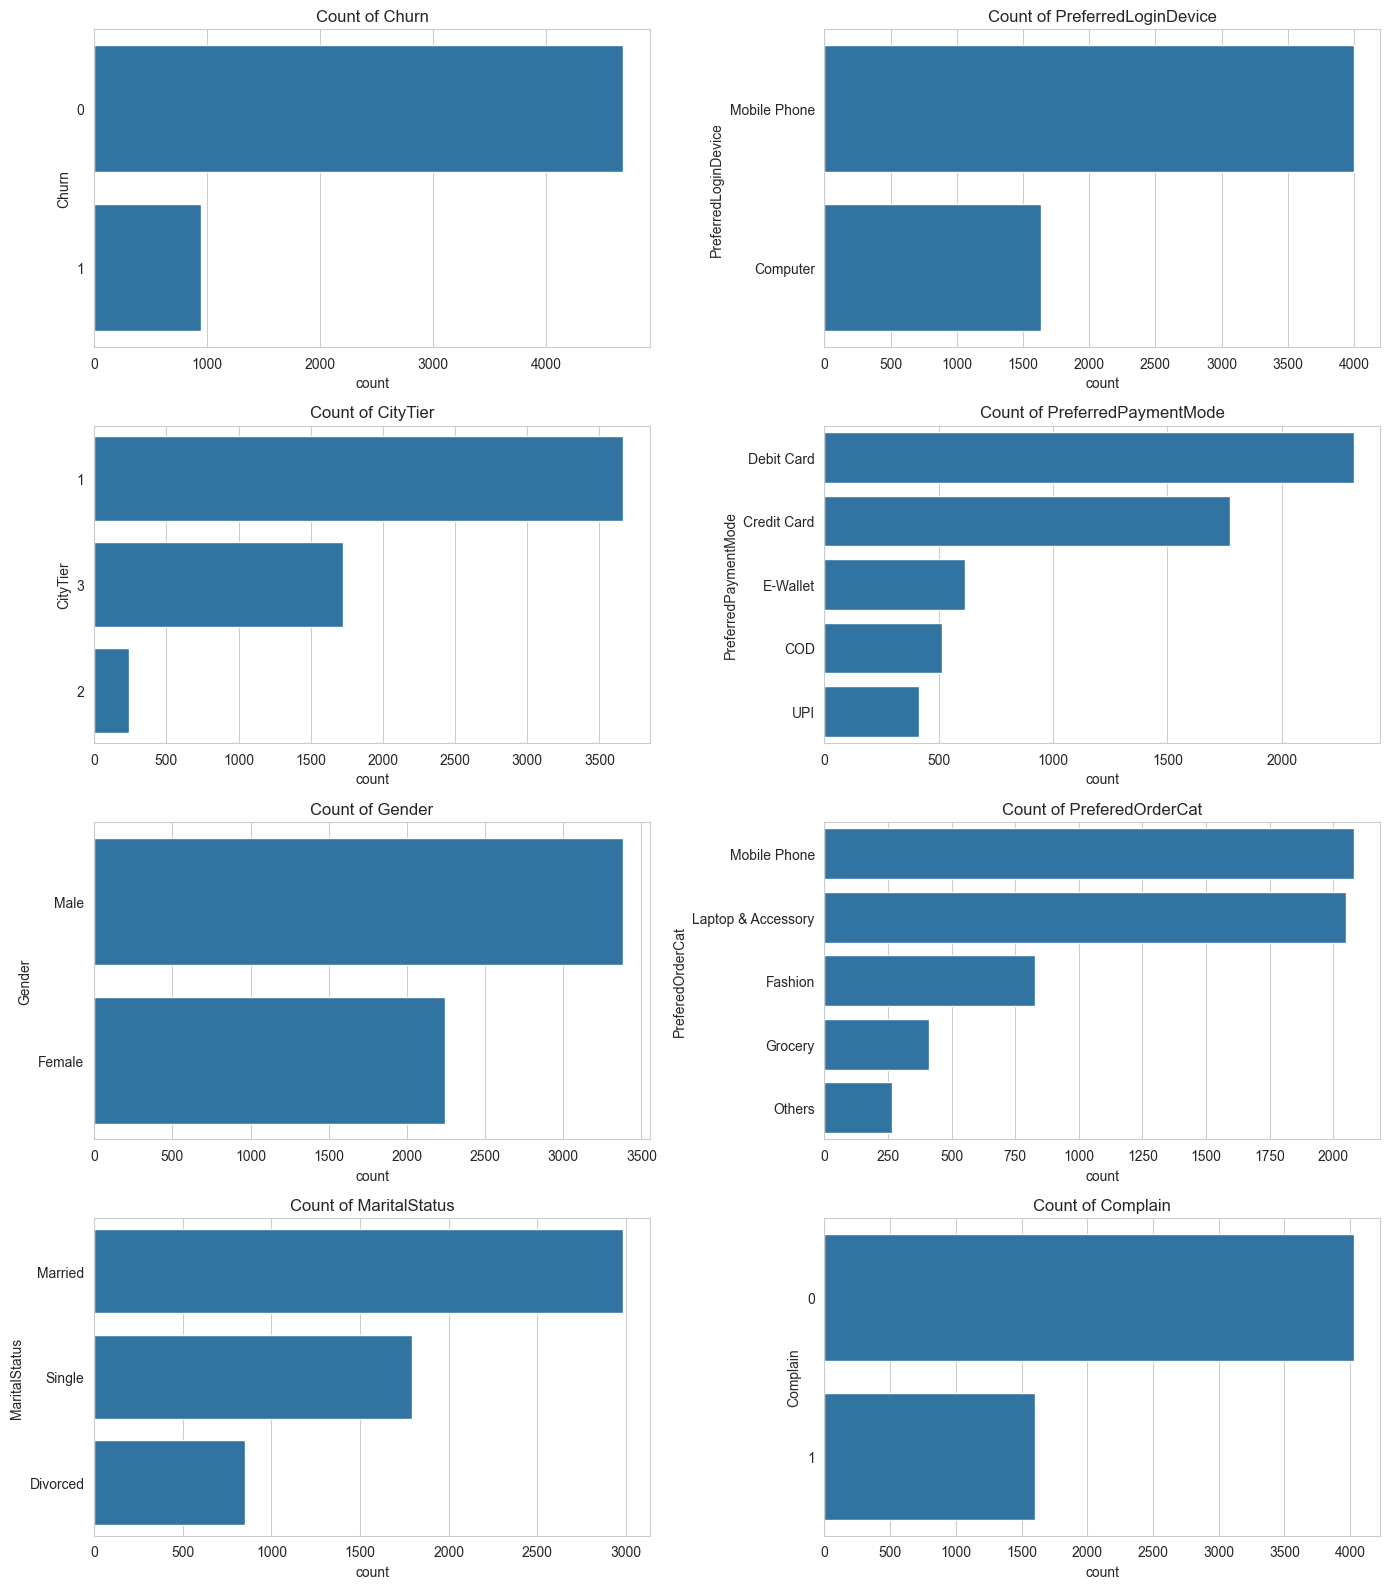

In [34]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col].astype(str), order=order, ax=axes[i])
    axes[i].set_title(f'Count of {col}')
plt.tight_layout()
plt.show()


**Findings:**
- **Churn:** confirms the 83.2% / 16.8% split — this is the baseline every later comparison gets measured against.
- **CityTier:** Tier 1 (65%) and Tier 3 (31%) dominate; Tier 2 is only 4.3% (~242 rows) — any churn finding for Tier 2 needs to be flagged as low-sample, not treated as a firm result.
- **PreferedOrderCat, PreferredPaymentMode, PreferredLoginDevice:** counts confirm the standardization in Section 5 worked correctly (Mobile Phone = 2,080 matches the expected merge total).
- **Complain:** 28.5% of customers have filed a complaint at some point — notably higher than the 16.8% overall churn rate, which is an early hint that complaining doesn't automatically mean leaving (investigated properly in Section 8).

## 7. Feature Engineering — Bucket Columns

Three of the core business questions need bucketed versions of continuous columns, so these are built here before bivariate analysis rather than inline.

In [35]:
def tenure_bucket(t):
    if t <= 6: return '0-6mo'
    elif t <= 12: return '6-12mo'
    elif t <= 24: return '1-2yr'
    else: return '2yr+'

df['Tenure_Bucket'] = df['Tenure'].apply(tenure_bucket)
df['Tenure_Bucket'].value_counts()


Tenure_Bucket
0-6mo     2150
6-12mo    1584
1-2yr     1467
2yr+       429
Name: count, dtype: int64

In [36]:
def recency_bucket(d):
    if d <= 2: return '0-2 days'
    elif d <= 7: return '3-7 days'
    elif d <= 15: return '8-15 days'
    else: return '16+ days'

df['Recency_Bucket'] = df['DaySinceLastOrder'].apply(recency_bucket)
df['Recency_Bucket'].value_counts()


Recency_Bucket
3-7 days     2426
0-2 days     1902
8-15 days    1259
16+ days       43
Name: count, dtype: int64

In [37]:
def freq_bucket(o):
    if o <= 2: return 'Low (1-2)'
    elif o <= 5: return 'Medium (3-5)'
    else: return 'High (6+)'

df['Order_Frequency_Bucket'] = df['OrderCount'].apply(freq_bucket)
df['Order_Frequency_Bucket'].value_counts()


Order_Frequency_Bucket
Low (1-2)       4034
High (6+)        840
Medium (3-5)     756
Name: count, dtype: int64

**Note:** bucket ranges were chosen based on each column's actual distribution (e.g. Recency buckets rescaled to the real 0–46 day range in this dataset), not arbitrary round numbers — a bucket scheme that leaves most bins empty isn't useful for analysis.

## 8. Bivariate Analysis — Everything Against Churn

From here on, every comparison is measured against the 16.8% overall churn rate. A segment sitting meaningfully above or below that baseline is a real signal; anything close to it isn't.

#### Churn by demographic segment (Gender, MaritalStatus, CityTier)


--- Churn rate by Gender ---
        mean  count
Gender             
Female  0.15   2246
Male    0.18   3384

--- Churn rate by MaritalStatus ---
               mean  count
MaritalStatus             
Divorced       0.15    848
Married        0.12   2986
Single         0.27   1796

--- Churn rate by CityTier ---
          mean  count
CityTier             
1         0.15   3666
2         0.20    242
3         0.21   1722


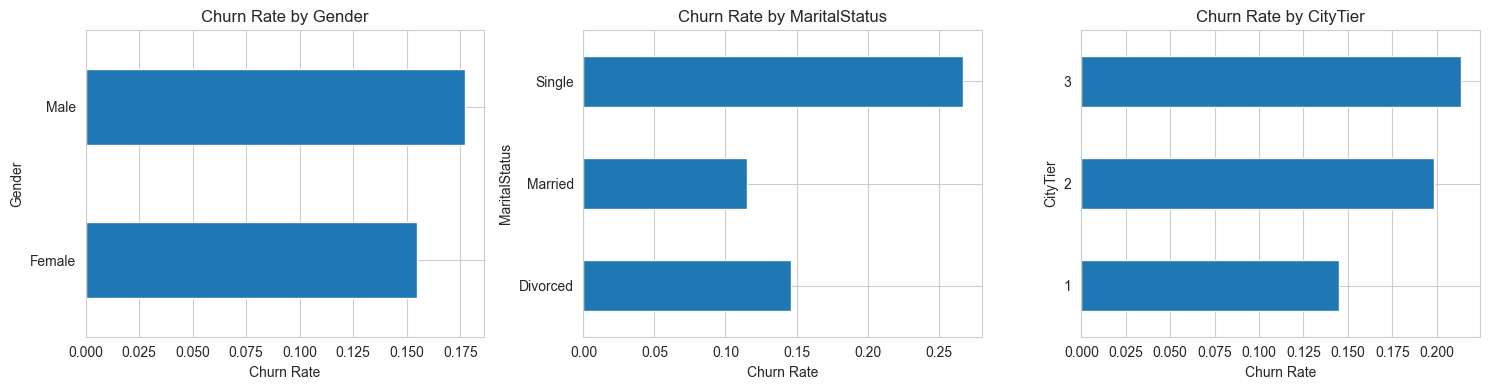

In [38]:
for col in ['Gender', 'MaritalStatus', 'CityTier']:
    print(f"\n--- Churn rate by {col} ---")
    print(df.groupby(col)['Churn'].agg(['mean','count']).round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['Gender', 'MaritalStatus', 'CityTier']):
    df.groupby(col)['Churn'].mean().plot(kind='barh', ax=axes[i])
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_xlabel('Churn Rate')
plt.tight_layout()
plt.show()


**Findings:**
- **Gender:** 15% (Female) vs 18% (Male) — a small gap, not a meaningful driver on its own.
- **MaritalStatus:** Single customers churn notably more (27%) than Married (12%) or Divorced (15%) — a real, moderate signal, backed by a solid sample size (1,796 Single customers).
- **CityTier:** Tier 3 shows the highest churn (21%), but Tier 2's 20% is based on only 242 customers — worth mentioning as directional, not conclusive.

#### Churn by Tenure


--- Churn rate by Tenure Bucket ---
               mean  count
Tenure_Bucket             
0-6mo          0.32   2150
1-2yr          0.06   1467
2yr+           0.00    429
6-12mo         0.10   1584


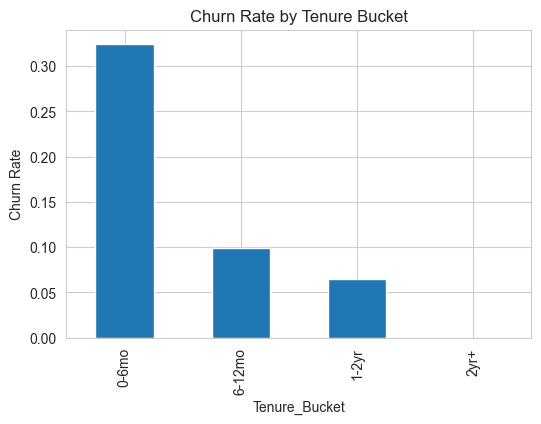

In [39]:
print("\n--- Churn rate by Tenure Bucket ---")
print(df.groupby('Tenure_Bucket')['Churn'].agg(['mean','count']).round(2))

plt.figure(figsize=(6,4))
df.groupby('Tenure_Bucket')['Churn'].mean().reindex(['0-6mo','6-12mo','1-2yr','2yr+']).plot(kind='bar')
plt.title('Churn Rate by Tenure Bucket')
plt.ylabel('Churn Rate')
plt.show()


**Finding — the strongest single driver in the whole dataset.** Churn drops in an almost perfect staircase with tenure: 0-6mo (32%) → 6-12mo (10%) → 1-2yr (6%) → 2yr+ (0%, n=429). Customers who've stuck around 2+ years essentially never leave. If this project has one headline finding, it's this.

#### Churn by Satisfaction Score and Complaints


--- Churn rate by Satisfaction Score ---
                   mean  count
SatisfactionScore             
1                  0.12   1164
2                  0.13    586
3                  0.17   1698
4                  0.17   1074
5                  0.24   1108


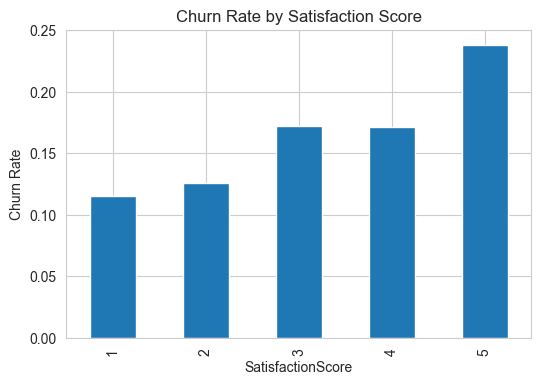

In [40]:
print("\n--- Churn rate by Satisfaction Score ---")
print(df.groupby('SatisfactionScore')['Churn'].agg(['mean','count']).round(2))

plt.figure(figsize=(6,4))
df.groupby('SatisfactionScore')['Churn'].mean().plot(kind='bar')
plt.title('Churn Rate by Satisfaction Score')
plt.ylabel('Churn Rate')
plt.show()


In [41]:
print("\n--- Churn rate by Complain ---")
print(df.groupby('Complain')['Churn'].agg(['mean','count']).round(2))



--- Churn rate by Complain ---
          mean  count
Complain             
0         0.11   4026
1         0.32   1604


**Finding — a genuine contradiction** Churn actually *rises* with reported satisfaction (Score 1: 12% churn vs Score 5: 24% churn) — backwards. Meanwhile, Complain shows a strong, intuitive gap: 11% churn with no complaint vs 32% with one — a 3x difference. These two are related, not two separate stories — see the investigation in Section 9.

#### Churn by Recency and App Engagement

In [42]:
print("\n--- Churn rate by Recency Bucket ---")
print(df.groupby('Recency_Bucket')['Churn'].agg(['mean','count']).round(2))

print("\n--- Churn rate by HourSpendOnApp ---")
print(df.groupby('HourSpendOnApp')['Churn'].agg(['mean','count']).round(2))



--- Churn rate by Recency Bucket ---
                mean  count
Recency_Bucket             
0-2 days        0.25   1902
16+ days        0.02     43
3-7 days        0.14   2426
8-15 days       0.10   1259

--- Churn rate by HourSpendOnApp ---
                mean  count
HourSpendOnApp             
0.0             0.00      3
1.0             0.00     35
2.0             0.16   1471
3.0             0.18   2942
4.0             0.17   1176
5.0             0.00      3


**Finding — another apparent contradiction.** Customers who ordered most recently (0-2 days) show the *highest* churn (25%), not the lowest. `HourSpendOnApp` shows no real pattern once the tiny 0/5-hour groups (n=3 each) are set aside as noise — churn sits flat around 16-18% across the real range (2, 3, 4 hours). The recency contradiction is investigated in Section 9.

#### Churn by Product Category and Order Frequency

In [43]:
print("\n--- Churn rate by PreferedOrderCat ---")
print(df.groupby('PreferedOrderCat')['Churn'].agg(['mean','count']).round(2).sort_values('mean', ascending=False))



--- Churn rate by PreferedOrderCat ---
                    mean  count
PreferedOrderCat               
Mobile Phone        0.27   2080
Fashion             0.15    826
Laptop & Accessory  0.10   2050
Others              0.08    264
Grocery             0.05    410


In [44]:
print("\n--- Churn rate by Order Frequency Bucket ---")
print(df.groupby('Order_Frequency_Bucket')['Churn'].agg(['mean','count']).round(2))



--- Churn rate by Order Frequency Bucket ---
                        mean  count
Order_Frequency_Bucket             
High (6+)               0.16    840
Low (1-2)               0.17   4034
Medium (3-5)            0.15    756


**Findings:**
- **PreferedOrderCat:** a real, strong spread — Mobile Phone buyers churn at 27%, more than 5x the rate of Grocery buyers (5%). Worth flagging to the business as a category-level risk, possibly tied to price competition being easier to shop around for phones than groceries.
- **Order_Frequency_Bucket:** flat across all three tiers (15-17%) — order frequency alone doesn't predict churn here, excluded from the final risk profile.

#### CashbackAmount vs Churn


--- CashbackAmount by Churn ---
         mean  median
Churn                
0      180.64  166.12
1      160.37  149.66


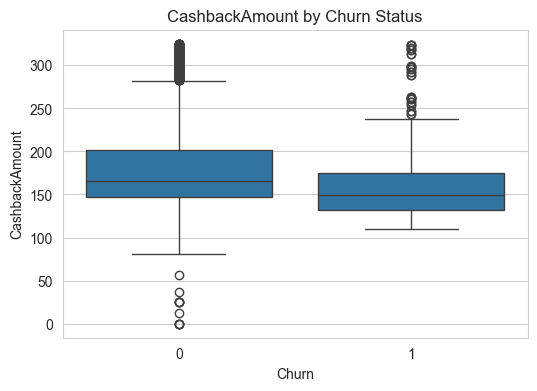

In [45]:
print("\n--- CashbackAmount by Churn ---")
print(df.groupby('Churn')['CashbackAmount'].agg(['mean','median']).round(2))

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='CashbackAmount', data=df)
plt.title('CashbackAmount by Churn Status')
plt.show()


**Finding:** churned customers received about ₹20 less cashback on average (₹160.37 vs ₹180.64) — a real but moderate gap, roughly 11%. Can't say whether lower cashback caused churn or reduced activity simply led to less cashback earned — the direction isn't clear from this alone, but the two are connected. This becomes useful later as the only ₹-denominated column available for sizing the retention opportunity.

## 9. Investigating the Two Contradictions

Two findings above didn't match intuition — satisfaction rising with churn, and recency being higher for churners. Rather than report them as-is, I dug one level deeper to find the real explanation underneath.

In [46]:
# Does Complain explain the Satisfaction contradiction?
df.groupby(['SatisfactionScore','Complain'])['Churn'].agg(['mean','count']).round(3)


mean  count
SatisfactionScore Complain              
1                 0         0.071    792
                  1         0.210    372
2                 0         0.077    416
                  1         0.247    170
3                 0         0.104   1226
                  1         0.347    472
4                 0         0.099    806
                  1         0.388    268
5                 0         0.183    786
                  1         0.373    322

**Solved.** Within every satisfaction level, complaining customers churn roughly 3x more than non-complainers (e.g. at Satisfaction=4: 9.9% vs 38.8%). Complain status is doing almost all of the real work here — the raw satisfaction-only view was misleading because satisfaction and complaints move together in a way that hides the real driver. **Conclusion: complaint status is a far more reliable churn signal than satisfaction score, and satisfaction alone should not be used as a churn predictor in this dataset.**

In [47]:
# Cross-check Recency against Tenure — are low-recency churners also low-tenure?
df.groupby(['Recency_Bucket','Tenure_Bucket'])['Churn'].mean().round(3).unstack()


Tenure_Bucket,0-6mo,1-2yr,2yr+,6-12mo
Recency_Bucket,,,,
0-2 days,0.432,0.069,0.0,0.154
16+ days,0.333,0.000,0.0,0.000
3-7 days,0.256,0.071,0.0,0.085
8-15 days,0.255,0.057,0.0,0.039


**Solved.** Even after controlling for tenure, recent order activity still shows *higher* churn within the same tenure bucket (e.g. in the 0-6mo group: 0-2 days recency → 43.2% churn vs 8-15 days → 25.5%). The likely explanation: a customer's final order right before they leave naturally shows up as "recent" in a snapshot dataset — so this is probably capturing the moment just before churn, not genuine ongoing engagement. Notably, 2yr+ tenure customers show 0% churn regardless of recency — long-tenured customers are stable no matter what.

## 10. Building the At-Risk Customer Segment

Bringing the confirmed strong drivers — Tenure, Complain, and PreferedOrderCat — together into a single combined risk score, to see whether stacking red flags actually sharpens the signal.

In [48]:
# Build a simple, defensible risk score using the confirmed strong drivers
df['Risk_Score'] = (
    (df['Tenure_Bucket'] == '0-6mo').astype(int) +
    (df['Complain'] == 1).astype(int) +
    (df['PreferedOrderCat'] == 'Mobile Phone').astype(int)
)

# Check churn rate at each risk score level (0 to 3 flags)
df.groupby('Risk_Score')['Churn'].agg(['mean','count']).round(2)


,mean,count
Risk_Score,,
0,0.04,1830
1,0.11,2128
2,0.31,1310
3,0.68,362


**Finding:** stacking the three flags produces a clean, dramatic staircase — 0 flags: 4% churn, 1 flag: 11%, 2 flags: 31%, 3 flags: 68%. A customer with all three red flags churns 17x more often than one with none. This confirms the three factors aren't just individually interesting — combined, they form a genuinely strong early-warning signal.

In [49]:
high_risk = df[df['Risk_Score'] >= 2]
print(f"High-risk customers (2+ flags): {len(high_risk)} ({len(high_risk)/len(df)*100:.1f}% of customer base)")
print(f"Average cashback tied to this group: ₹{high_risk['CashbackAmount'].mean():.2f}")
print(f"Total cashback exposure: ₹{high_risk['CashbackAmount'].sum():.2f}")


High-risk customers (2+ flags): 1672 (29.7% of customer base)
Average cashback tied to this group: ₹148.17
Total cashback exposure: ₹247735.05


**Finding:** 1,672 customers — about 30% of the entire customer base — carry 2 or more risk flags, representing ₹247,735 in cashback/reward exposure. This is not a small edge case; nearly a third of customers sit in the danger zone.

**This is the project's central conclusion:** customers who are new (under 6 months), have filed a complaint, and mainly buy mobile phones are the group most likely to churn — and they represent a large, quantifiable share of the business. Long-tenured customers, regardless of any other factor, are essentially safe. Retention spend should prioritize the 362 customers carrying all three flags first (68% churn rate), then expand to the full 1,672-customer at-risk group.

## 11. Export Cleaned + Engineered Data

Saving the final dataset — cleaned, standardized, with all missingness flags, bucket columns, and the Risk_Score — ready to load into SQL for the next stage.

In [54]:
from pathlib import Path

output_dir = Path("data") / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(output_dir / "ecommerce_churn_cleaned.csv", index=False)

print("Exported:", df.shape)
print(df.columns.tolist())


Exported: (5630, 30)
['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'Tenure_Missing', 'WarehouseToHome_Missing', 'HourSpendOnApp_Missing', 'OrderCount_Missing', 'CouponUsed_Missing', 'OrderAmountHike_Missing', 'Tenure_Bucket', 'Recency_Bucket', 'Order_Frequency_Bucket', 'Risk_Score']


## Summary of Cleaning & Feature Engineering Decisions

1. Capped 2 extreme `WarehouseToHome` values (126, 127) at 40 — likely decimal entry errors, capped rather than dropped to preserve the rest of each row's data.
2. Checked whether missingness in the 7 null-containing columns correlated with churn before imputing. Found 6 of the 7 do (3 in each direction) — created a missingness flag for each before median-imputing, so the signal isn't lost. DaySinceLastOrder showed no relationship and was imputed directly.
3. Standardized 3 categorical columns where the source data used inconsistent labels for the same real-world category (`PreferredLoginDevice`, `PreferredPaymentMode`, `PreferedOrderCat`).
4. Verified `Gender` and `MaritalStatus` had no similar inconsistencies rather than assuming.
5. Engineered 3 bucket columns (`Tenure_Bucket`, `Recency_Bucket`, `Order_Frequency_Bucket`) scaled to this dataset's actual ranges, not arbitrary round numbers.
6. Investigated two counterintuitive findings (satisfaction and recency both showing "backwards" relationships with churn) rather than reporting them at face value — both were explained by confounding with Complain and Tenure respectively.
7. Built a combined `Risk_Score` from the three confirmed strongest drivers (Tenure, Complain, PreferedOrderCat), validated it produces a genuine escalating churn pattern, and sized the at-risk segment in customer count and ₹ exposure.



## 12. Key Findings & Recommendations

**Key Findings:**
1. Tenure is the dominant churn driver — churn drops from 32% (0-6mo) to 0% (2yr+).
2. Complaint status matters far more than satisfaction score — a complaint triples 
   churn risk at every satisfaction level.
3. Mobile Phone buyers churn 5x more than Grocery buyers.
4. Combining these three factors into a risk score shows a 17x churn gap between 
   customers with 0 flags vs 3 flags (4% vs 68%).
5. 1,672 customers (~30% of the base) carry 2+ risk flags, representing ₹247,735 
   in cashback exposure.

**Recommendations (ranked):**
1. Prioritize retention outreach for the 362 customers with all 3 risk flags 
   (68% churn rate) — highest urgency, smallest group.
2. Build an early-intervention program for customers in their first 6 months, 
   since this is where churn risk is structurally highest regardless of other factors.
3. Fast-track complaint resolution — since complaint status nearly triples churn 
   risk independent of stated satisfaction, response speed/quality may matter more 
   than the satisfaction survey itself.

**Limitations:** This dataset is a single snapshot, not a purchase history — 
findings describe association, not proven causation (especially for Complain, 
Recency, and CashbackAmount, as discussed in Section 9).